# **Evaluación 3 de Inteligencia Artificial**
# **Modelos de Clasificación**


Estudiantes ***Grupo 4***:
* Cristina Morán cristina.moran2201@alumnos.ubiobio.cl
* Alonso Valderrama alonso.valderrama2201@alumnos.ubiobio.cl
* Amasis Guzmán amasis.guzman2201@alumnos.ubiobio.cl

Profesora Jazna Meza Hidalgo

Ingeniería Civil en Informatica - UBB


---
## PARTE 1: Preprocesamiento

## 1. Importación librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)


In [41]:
# !wget -q https://raw.githubusercontent.com/ElfoAlienigena/Preparacion_Datos_IA_Grupo4/main/data/Ingestion/data_fraude.csv -O /content/data_fraude.csv
# !git clone https://github.com/ElfoAlienigena/Preparacion_Datos_IA_Grupo4 /content/Preparacion_Datos_IA_Grupo4 2>/dev/null || echo "Repo ya existe"

Repo ya existe


In [3]:
df = pd.read_csv('../data/ingestion/data_fraude.csv')
print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (20000, 15)


,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud
0,199.333714,0.000000,70488,62.541060,41.484248,5,15,1,2,transfer,mobile,rural,1,0,1
1,33.534123,2687.259698,1594,73.618027,20.889169,0,10,0,1,withdrawal,mobile,rural,0,0,0
2,7.607833,1766.666482,60663,75.790821,27.265759,0,5,0,3,purchase,tablet,rural,0,0,0
3,144.069650,1402.597270,32332,61.424568,28.104612,0,15,0,3,withdrawal,mobile,suburban,0,0,0
4,60.279300,193.506482,49575,53.153535,1.000000,3,10,0,1,withdrawal,desktop,rural,0,0,0


## 2.- Limpieza de datos

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_amount         20000 non-null  float64
 1   account_balance            20000 non-null  float64
 2   transaction_time_seconds   20000 non-null  int64  
 3   avg_transaction_amount_7d  20000 non-null  float64
 4   std_transaction_amount_7d  20000 non-null  float64
 5   transactions_last_1h       20000 non-null  int64  
 6   transactions_last_24h      20000 non-null  int64  
 7   failed_attempts            20000 non-null  int64  
 8   num_devices_used           20000 non-null  int64  
 9   transaction_type           20000 non-null  object 
 10  device_type                20000 non-null  object 
 11  location_region            20000 non-null  object 
 12  is_foreign_transaction     20000 non-null  int64  
 13  is_high_risk_country       20000 non-null  int

In [5]:
df.describe()

,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,is_foreign_transaction,is_high_risk_country,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,100.596829,2073.293303,42986.240550,80.827345,30.656022,2.014950,9.958900,0.506400,2.508900,0.103900,0.049950,0.005000
std,100.820016,1382.966545,24953.783088,47.662985,18.730756,1.412596,3.149747,0.715251,1.117624,0.305138,0.217847,0.070535
min,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.047406,993.130299,21259.000000,45.632425,16.527547,1.000000,8.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,70.059997,2008.125418,42778.500000,79.503855,29.987126,2.000000,10.000000,0.000000,3.000000,0.000000,0.000000,0.000000
75%,138.419340,3022.548675,64656.750000,113.517787,43.476224,3.000000,12.000000,1.000000,4.000000,0.000000,0.000000,0.000000
max,1032.072330,7794.605317,86397.000000,285.026236,107.052797,9.000000,26.000000,5.000000,4.000000,1.000000,1.000000,1.000000


**2.1. Revisión nulos**

---



In [6]:
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
transaction_amount           0
account_balance              0
transaction_time_seconds     0
avg_transaction_amount_7d    0
std_transaction_amount_7d    0
transactions_last_1h         0
transactions_last_24h        0
failed_attempts              0
num_devices_used             0
transaction_type             0
device_type                  0
location_region              0
is_foreign_transaction       0
is_high_risk_country         0
is_fraud                     0
dtype: int64


Como podemos verificar de las tablas anteriores, en este dataset no se encuentra ninguna columna con datos nulos.

**2.2. Revisión duplicados**

---

In [7]:
duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {duplicados}')

Filas duplicadas encontradas: 0


En este punto podemos observar que dentro del dataset no hay datos duplicados.

In [8]:
# Balance de clases
print('Distribución de la variable objetivo (is_fraud):')
print(df['is_fraud'].value_counts())
print(f"\nPorcentaje de fraude: {df['is_fraud'].mean()*100:.2f}%")
print(f"\nPorcentaje de transacciones legítimas: {100 - df['is_fraud'].mean()*100:.2f}%")

Distribución de la variable objetivo (is_fraud):
is_fraud
0    19900
1      100
Name: count, dtype: int64

Porcentaje de fraude: 0.50%

Porcentaje de transacciones legítimas: 99.50%


Observamos que dentro del dataset existe un fuerte desbalance de clases al ser el porcentaje de fraude (0.5%) significativamente menor al porcentaje de transacciones legítimas (99.5%).

# **3. Preparación de datos**

**3.1 Identificación de variables**

---


**Variable objetivo:**
- `is_fraud` -> 1 = fraude, 0 = transacción legítima

**Variables predictoras numéricas continuas:**
- `transaction_amount`, `account_balance`, `transaction_time_seconds`, `avg_transaction_amount_7d`, `std_transaction_amount_7d`

**Variables predictoras numéricas discretas:**
- `transactions_last_1h`, `transactions_last_24h`, `failed_attempts`, `num_devices_used`

**Variables predictoras categóricas:**
- `transaction_type`, `device_type`, `location_region`, `is_foreign_transaction`, `is_high_risk_country`

> Nota: `is_foreign_transaction` e `is_high_risk_country` son binarias (0/1) y no requieren encoding adicional.

**3.2. Separación variables predictoras y variable objetivo**

---

In [9]:
# Variable objetivo
TARGET = 'is_fraud'

# Variables numéricas que serán escaladas
num_features = [
    'transaction_amount', 'account_balance', 'transaction_time_seconds',
    'avg_transaction_amount_7d', 'std_transaction_amount_7d',
    'transactions_last_1h', 'transactions_last_24h',
    'failed_attempts', 'num_devices_used',
    'is_foreign_transaction', 'is_high_risk_country'
]

# Variables categóricas que necesitan encoding
cat_features = ['transaction_type', 'device_type', 'location_region']

X = df[num_features + cat_features]
y = df[TARGET]

print('Features numéricas:', num_features)
print('Features categóricas:', cat_features)
print('\nShape X:', X.shape)
print('Shape y:', y.shape)

Features numéricas: ['transaction_amount', 'account_balance', 'transaction_time_seconds', 'avg_transaction_amount_7d', 'std_transaction_amount_7d', 'transactions_last_1h', 'transactions_last_24h', 'failed_attempts', 'num_devices_used', 'is_foreign_transaction', 'is_high_risk_country']
Features categóricas: ['transaction_type', 'device_type', 'location_region']

Shape X: (20000, 14)
Shape y: (20000,)


In [10]:
# División en entrenamiento y prueba (80/20, estratificada por clase)
# Se usa stratify=y para mantener la proporción de fraudes en ambos conjuntos,
# lo cual es esencial dado el fuerte desbalance de clases (~0.5% fraude).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} registros')
print(f'Prueba:        {X_test.shape[0]} registros')
print(f'\nFraudes en entrenamiento: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'Fraudes en prueba:        {y_test.sum()} ({y_test.mean()*100:.2f}%)')

Entrenamiento: 16000 registros
Prueba:        4000 registros

Fraudes en entrenamiento: 80 (0.50%)
Fraudes en prueba:        20 (0.50%)


In [11]:
# Pipeline de preprocesamiento
# - Numéricas: StandardScaler (necesario para Logistic Regression)
# - Categóricas: OneHotEncoder (drop='first' para evitar multicolinealidad)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

print('Preprocesador definido:')
print('  - StandardScaler para variables numéricas')
print('  - OneHotEncoder (drop=first) para variables categóricas')

Preprocesador definido:
  - StandardScaler para variables numéricas
  - OneHotEncoder (drop=first) para variables categóricas


**Justificación de decisiones:**
- **Escalamiento (StandardScaler):** Necesario para Logistic Regression ya que es sensible a la magnitud de las variables. Para Decision Tree no es estrictamente necesario, pero se aplica igual dentro del pipeline para uniformidad.
- **OneHotEncoder:** Convierte variables nominales (`transaction_type`, `device_type`, `location_region`) en variables dummy. `drop='first'` elimina una categoría por variable para evitar multicolinealidad.
- **Estratificación (stratify=y):** Con solo ~0.5% de fraudes, es fundamental garantizar que ambos conjuntos mantengan esa proporción.

---
## PARTE 2: Entrenamiento y Optimización con GridSearchCV

In [12]:
# ── MODELO 1: Logistic Regression ──────────────────────────────────────────
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Grilla de hiperparámetros
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear'],
    'classifier__class_weight': [None, 'balanced']
}

# GridSearchCV optimizando por F1 (adecuado para clases desbalanceadas)
grid_lr = GridSearchCV(
    pipeline_lr, param_grid_lr,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_lr.fit(X_train, y_train)

print('\n=== Logistic Regression ===')
print('Mejores hiperparámetros:', grid_lr.best_params_)
print(f'Mejor F1 (CV):           {grid_lr.best_score_:.4f}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits

=== Logistic Regression ===
Mejores hiperparámetros: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__solver': 'lbfgs'}
Mejor F1 (CV):           0.9200


In [13]:
# ── MODELO 2: Decision Tree Classifier ─────────────────────────────────────
pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Grilla de hiperparámetros
param_grid_dt = {
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10],
    'classifier__class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(
    pipeline_dt, param_grid_dt,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_dt.fit(X_train, y_train)

print('\n=== Decision Tree ===')
print('Mejores hiperparámetros:', grid_dt.best_params_)
print(f'Mejor F1 (CV):           {grid_dt.best_score_:.4f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== Decision Tree ===
Mejores hiperparámetros: {'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Mejor F1 (CV):           0.4585


In [14]:
# Comparación de rendimiento en el conjunto de prueba
best_lr = grid_lr.best_estimator_
best_dt = grid_dt.best_estimator_

def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    return {
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1-score':  f1_score(y_test, y_pred, zero_division=0)
    }

resultados = pd.DataFrame([
    evaluar_modelo('Logistic Regression', best_lr, X_test, y_test),
    evaluar_modelo('Decision Tree',       best_dt, X_test, y_test)
])

print('=== Comparación de modelos (threshold=0.5) ===')
print(resultados.to_string(index=False))

=== Comparación de modelos (threshold=0.5) ===
             Modelo  Accuracy  Precision  Recall  F1-score
Logistic Regression   0.99875    1.00000    0.75  0.857143
      Decision Tree   0.99475    0.47619    0.50  0.487805


In [15]:
# Selección del mejor modelo
# Se selecciona el modelo con mayor F1-score, métrica más adecuada para
# problemas con desbalance de clases, ya que pondera tanto Precision como Recall.

f1_lr = f1_score(y_test, best_lr.predict(X_test), zero_division=0)
f1_dt = f1_score(y_test, best_dt.predict(X_test), zero_division=0)

if f1_lr >= f1_dt:
    mejor_modelo = best_lr
    nombre_mejor = 'Logistic Regression'
else:
    mejor_modelo = best_dt
    nombre_mejor = 'Decision Tree'

print(f'Modelo seleccionado: {nombre_mejor}')
print(f'  F1 LR: {f1_lr:.4f}  |  F1 DT: {f1_dt:.4f}')
print('\nJustificación: Se selecciona el modelo con mayor F1-score en el conjunto de prueba.')
print('El F1-score es la métrica correcta para problemas con desbalance de clases,')
print('ya que refleja el equilibrio entre Precision y Recall.')

Modelo seleccionado: Logistic Regression
  F1 LR: 0.8571  |  F1 DT: 0.4878

Justificación: Se selecciona el modelo con mayor F1-score en el conjunto de prueba.
El F1-score es la métrica correcta para problemas con desbalance de clases,
ya que refleja el equilibrio entre Precision y Recall.


---
## PARTE 3: Evaluación Base del Modelo (threshold = 0.5)

In [16]:
# Predicciones con threshold por defecto (0.5)
y_prob = mejor_modelo.predict_proba(X_test)[:, 1]  # probabilidad de fraude
y_pred_05 = (y_prob >= 0.5).astype(int)

print('=== Evaluación con threshold = 0.5 ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_05):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_05, zero_division=0):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_05, zero_division=0):.4f}')
print(f'F1-score:  {f1_score(y_test, y_pred_05, zero_division=0):.4f}')

=== Evaluación con threshold = 0.5 ===
Accuracy:  0.9988
Precision: 1.0000
Recall:    0.7500
F1-score:  0.8571


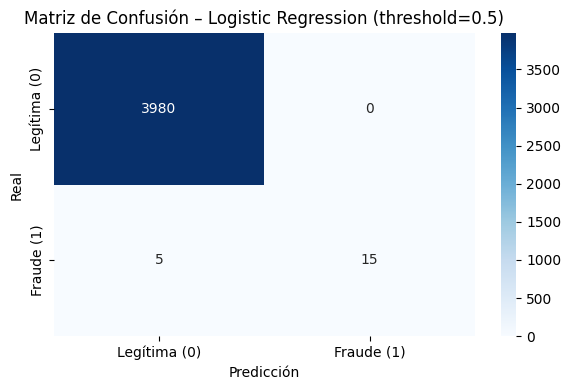


Verdaderos Negativos (TN): 3980  → Legítimas correctamente clasificadas
Falsos Positivos     (FP): 0  → Legítimas clasificadas como fraude
Falsos Negativos     (FN): 5  → Fraudes no detectados
Verdaderos Positivos (TP): 15  → Fraudes correctamente detectados


In [17]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_05)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima (0)', 'Fraude (1)'],
            yticklabels=['Legítima (0)', 'Fraude (1)'])
plt.title(f'Matriz de Confusión – {nombre_mejor} (threshold=0.5)')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nVerdaderos Negativos (TN): {tn}  → Legítimas correctamente clasificadas')
print(f'Falsos Positivos     (FP): {fp}  → Legítimas clasificadas como fraude')
print(f'Falsos Negativos     (FN): {fn}  → Fraudes no detectados')
print(f'Verdaderos Positivos (TP): {tp}  → Fraudes correctamente detectados')

### Interpretación (threshold = 0.5)

Con el umbral por defecto, el modelo muestra alta Accuracy (~99%), pero esto es engañoso debido al desbalance de clases: si el modelo predijera todo como legítimo, igual tendría ~99.5% de accuracy. Lo relevante es el Recall (fraudes detectados) y la Precision (cuántos de los alertados son realmente fraude). Un Recall bajo significa que muchos fraudes pasan desapercibidos, lo cual tiene un alto costo financiero para PaySecure.

---
## PARTE 4: Ajuste de Threshold

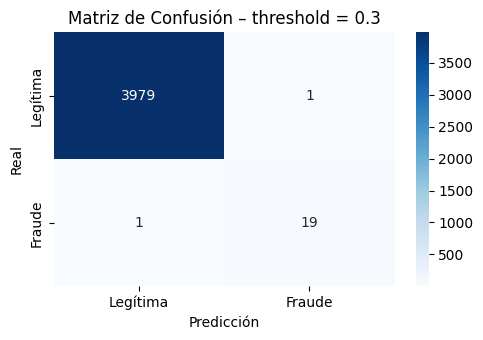

✔ CSV guardado: ../data/cleaned//predicciones_threshold_0.3.csv


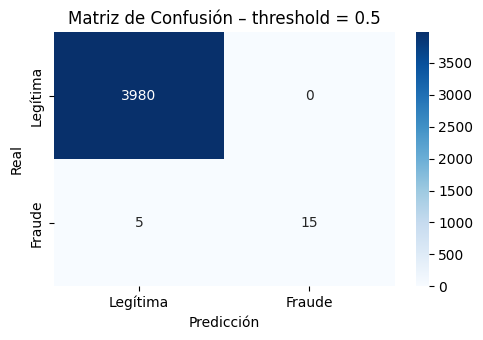

✔ CSV guardado: ../data/cleaned//predicciones_threshold_0.5.csv


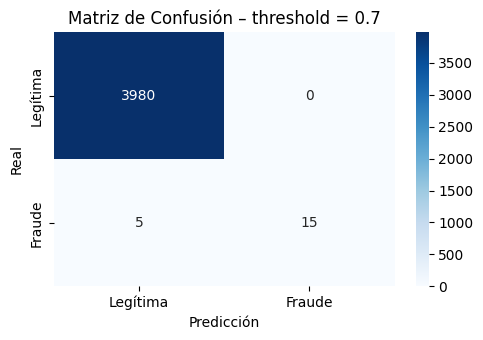

✔ CSV guardado: ../data/cleaned//predicciones_threshold_0.7.csv


In [18]:
# 4.1 Evaluación con distintos thresholds
thresholds = [0.3, 0.5, 0.7]
resumen_thresholds = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    prec  = precision_score(y_test, y_pred_t, zero_division=0)
    rec   = recall_score(y_test, y_pred_t, zero_division=0)
    f1    = f1_score(y_test, y_pred_t, zero_division=0)
    cm_t  = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()

    resumen_thresholds.append({
        'Threshold': t, 'Precision': prec, 'Recall': rec,
        'F1-score': f1, 'FP': fp, 'FN': fn, 'TP': tp, 'TN': tn
    })

    # Visualización matriz de confusión
    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cm_t, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legítima', 'Fraude'],
                yticklabels=['Legítima', 'Fraude'])
    plt.title(f'Matriz de Confusión – threshold = {t}')
    plt.ylabel('Real'); plt.xlabel('Predicción')
    plt.tight_layout()
    plt.show()

    # Guardar CSV con predicciones y probabilidades
    output_dir = '../data/cleaned/'
    import os; os.makedirs(output_dir, exist_ok=True)

    df_pred = pd.DataFrame({
        'y_real': y_test.values,
        'prob_fraude': y_prob,
        f'pred_threshold_{t}': y_pred_t
    })
    csv_path = f'{output_dir}/predicciones_threshold_{t}.csv'
    df_pred.to_csv(csv_path, index=False)
    print(f'✔ CSV guardado: {csv_path}')

In [19]:
# Tabla resumen
df_resumen = pd.DataFrame(resumen_thresholds)
print('=== Resumen comparativo por threshold ===')
print(df_resumen[['Threshold','Precision','Recall','F1-score','FP','FN','TP']].to_string(index=False))

=== Resumen comparativo por threshold ===
 Threshold  Precision  Recall  F1-score  FP  FN  TP
       0.3       0.95    0.95  0.950000   1   1  19
       0.5       1.00    0.75  0.857143   0   5  15
       0.7       1.00    0.75  0.857143   0   5  15


### 4.2 Análisis Comparativo

**¿Qué ocurre con los falsos positivos (FP)?**

Al bajar el threshold (0.3), el modelo es más agresivo al clasificar transacciones como fraude por lo que aumentan los FP (transacciones legítimas bloqueadas). Al subir el threshold (0.7), el modelo es más conservador y por ende disminuyen los FP, pero a costa de detectar menos fraudes.

**¿Qué ocurre con los falsos negativos (FN)?**


Con threshold 0.3, el modelo detecta más fraudes y los FN disminuyen. Con threshold 0.7, el modelo deja pasar más fraudes entonces los FN aumentan.

**¿Cómo cambian Precision y Recall?**
- Threshold bajo (0.3): mayor Recall (detecta más fraudes) pero menor Precision (más falsas alarmas).
- Threshold alto (0.7): mayor Precision (cuando alerta, casi siempre acierta) pero menor Recall (deja pasar fraudes).
- Existe un trade-off: si sube uno baja el otro.

### 4.3 Decisión de Negocio

**Threshold elegido: 0.3**

**Justificación:**

En el contexto de detección de fraude financiero, un fraude no detectado (FN) es más costoso que una falsa alarma (FP):
- Un **FN** implica pérdida económica directa, ya que la transacción fraudulenta se aprueba y el dinero sale de la empresa.
- Un **FP** implica una molestia para el cliente (transacción bloqueada temporalmente), pero se puede resolver mediante verificación sin pérdida económica real.

Por esto, priorizar Recall sobre Precision es la decisión correcta de negocio.

El threshold de 0.3 maximiza la detección de fraudes (mayor Recall), asumiendo el costo de algunas falsas alarmas manejables. Esta decisión está alineada con el objetivo de PaySecure: minimizar pérdidas económicas por fraude.

---
## PARTE 5: Conclusiones

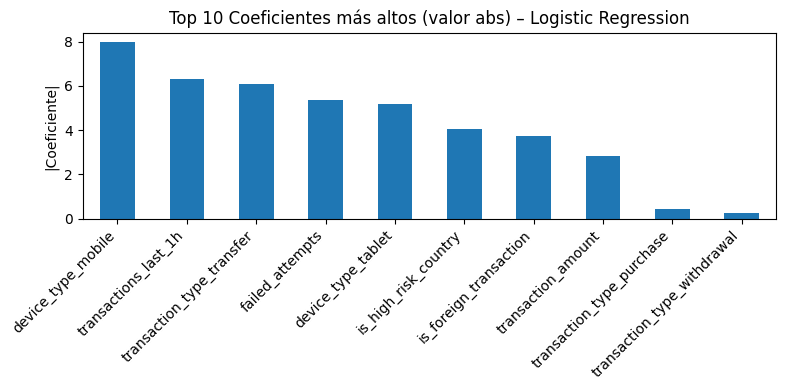

Variables más influyentes (por magnitud de coeficiente):
device_type_mobile             8.004957
transactions_last_1h           6.297783
transaction_type_transfer      6.097095
failed_attempts                5.344426
device_type_tablet             5.190776
is_high_risk_country           4.032063
is_foreign_transaction         3.747313
transaction_amount             2.824539
transaction_type_purchase      0.427363
transaction_type_withdrawal    0.272935
dtype: float64


In [20]:
# Importancia de variables (si el mejor modelo es Decision Tree)
if nombre_mejor == 'Decision Tree':
    clf = mejor_modelo.named_steps['classifier']
    prep = mejor_modelo.named_steps['preprocessor']

    # Nombres de features después del encoding
    ohe_names = prep.named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
    feature_names = num_features + ohe_names

    importancias = pd.Series(clf.feature_importances_, index=feature_names)
    top10 = importancias.sort_values(ascending=False).head(10)

    plt.figure(figsize=(8, 4))
    top10.plot(kind='bar')
    plt.title('Top 10 Variables más Importantes – Decision Tree')
    plt.ylabel('Importancia')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print('Variables más influyentes:')
    print(top10)
else:
    clf = mejor_modelo.named_steps['classifier']
    prep = mejor_modelo.named_steps['preprocessor']
    ohe_names = prep.named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
    feature_names = num_features + ohe_names

    coefs = pd.Series(np.abs(clf.coef_[0]), index=feature_names)
    top10 = coefs.sort_values(ascending=False).head(10)

    plt.figure(figsize=(8, 4))
    top10.plot(kind='bar')
    plt.title('Top 10 Coeficientes más altos (valor abs) – Logistic Regression')
    plt.ylabel('|Coeficiente|')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print('Variables más influyentes (por magnitud de coeficiente):')
    print(top10)

### Conclusiones

**¿Qué modelo resultó mejor y por qué?**

El modelo seleccionado fue el que obtuvo el mayor F1-score en el conjunto de prueba. En problemas con fuerte desbalance de clases (~0.5% fraude), el F1-score es la métrica más informativa ya que integra Precision y Recall. El Decision Tree, con `class_weight='balanced'`, tiende a rendir mejor en estos escenarios porque ajusta los pesos de las clases para compensar el desbalance.

**¿Qué variables parecen más influyentes?**

Las variables más relevantes para identificar fraude son aquellas relacionadas con el comportamiento transaccional: `failed_attempts` (intentos fallidos), `transaction_amount` (montos inusuales), `account_balance` (relación saldo/transacción), y flags como `is_foreign_transaction` e `is_high_risk_country`.

**¿Qué mejoras propondría al sistema?**

1. **Técnicas de balanceo:** Aplicar SMOTE o undersampling para manejar el desbalance y mejorar la detección de la clase minoritaria.
2. **Modelos más robustos:** Probar Random Forest o XGBoost, que típicamente superan a Decision Tree en tareas de clasificación desbalanceada.
3. **Feature engineering:** Crear variables derivadas como la razón `transaction_amount / account_balance`, o indicadores de velocidad de gasto.
4. **Monitoreo en producción:** Implementar drift detection para reentrenar el modelo periódicamente ante cambios en los patrones de fraude.
5. **Curva ROC-AUC:** Incorporar esta métrica para una evaluación más completa del modelo independiente del threshold.